ideen: learning of the optimal teacher guidance during the process of dyad? 
frage: wie findet man einen dyad partner, der für einen am besten ist?
"How does the balance between autonomy and guidance affect the divergence and ultimate performance of learners in dyadic skill acquisition?"

=== Summary (last 50 episodes) ===
         solo: mean_reward_last50=11.758 | mean_steps_last50=14.42 | episodes_to_mastery=2
         dyad: mean_reward_last50=11.802 | mean_steps_last50=13.98 | episodes_to_mastery=2
 dyad_teacher: mean_reward_last50=14.573 | mean_steps_last50=13.42 | episodes_to_mastery=1

Mastery threshold (reward): 10.80 (piece length 12)


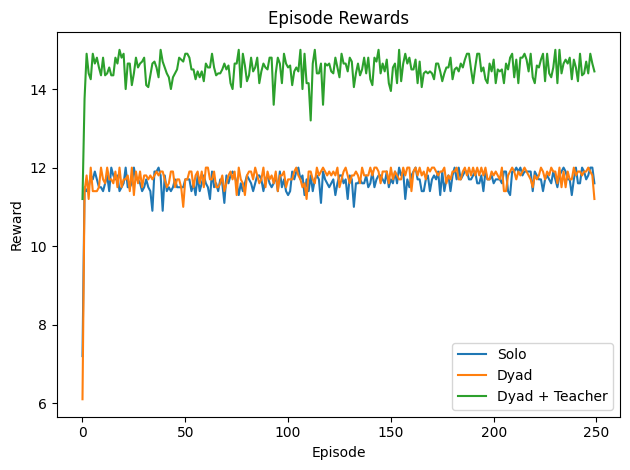

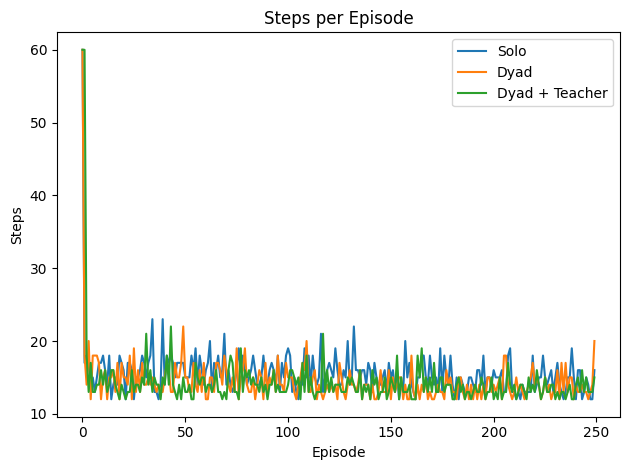

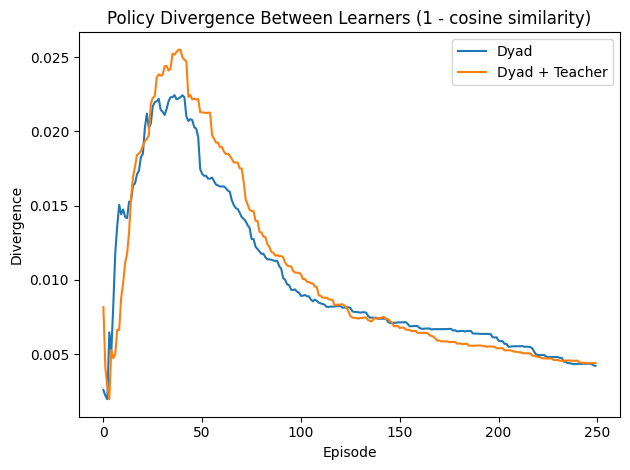

In [8]:

import math
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict

# ----------------------------
# Environment: Piano Piece MDP
# ----------------------------
# A simple sequential task: a "piece" has L note positions (states),
# each requires the correct action among A possible notes/keys.
# Reward: +1 for correct move (advance to next state), -0.1 otherwise.
# Episode ends when the piece is completed (reach terminal after L correct notes)
# or when a max step budget is reached.

class PianoEnv:
    def __init__(self, length: int = 8, n_actions: int = 5, max_steps: Optional[int] = None, seed: int = 0):
        self.length = length
        self.n_actions = n_actions
        self.state = 0
        self.rng = random.Random(seed)
        self.np_rng = np.random.default_rng(seed)
        # "Score" mapping from state -> correct action (fixed unknown function)
        self.correct_map = [self.rng.randrange(n_actions) for _ in range(length)]
        self.max_steps = max_steps if max_steps is not None else 5 * length

    def reset(self) -> int:
        self.state = 0
        self.steps = 0
        return self.state

    def step(self, action: int) -> Tuple[int, float, bool, Dict]:
        self.steps += 1
        done = False
        reward = -0.1
        if action == self.correct_map[self.state]:
            reward = 1.0
            self.state += 1
            if self.state >= self.length:
                done = True
        if self.steps >= self.max_steps:
            done = True
        return self.state, reward, done, {}

# ----------------------------
# Q-Learning Agent
# ----------------------------
@dataclass
class TalentProfile:
    alpha_init: float = 0.4          # initial learning rate
    alpha_decay: float = 0.001       # per-episode decay
    epsilon_init: float = 0.3        # initial exploration
    epsilon_min: float = 0.02
    epsilon_decay: float = 0.002     # per-episode decay
    gamma: float = 0.95
    hint_compliance: float = 0.5     # how strongly the agent follows hints (0..1)
    name: str = "learner"

class QLearningAgent:
    def __init__(self, n_states: int, n_actions: int, talent: TalentProfile, seed: int = 0):
        self.n_states = n_states
        self.n_actions = n_actions
        self.talent = talent
        self.rng = random.Random(seed)
        self.np_rng = np.random.default_rng(seed)
        # Small random Q init to diversify policies
        self.Q = self.np_rng.normal(loc=0.0, scale=0.01, size=(n_states, n_actions))
        self.episode = 0

    def epsilon(self) -> float:
        return max(self.talent.epsilon_min,
                   self.talent.epsilon_init * math.exp(-self.talent.epsilon_decay * self.episode))

    def alpha(self) -> float:
        return max(0.05, self.talent.alpha_init * math.exp(-self.talent.alpha_decay * self.episode))

    def act(self, state: int, hint: Optional[int] = None, hint_weight: float = 0.0) -> int:
        # Epsilon-greedy with hint bias (without merging Q tables)
        if self.rng.random() < self.epsilon():
            # explore, but if hint exists, bias toward hinted action with hint_weight
            if hint is not None and self.rng.random() < hint_weight:
                return hint
            return self.rng.randrange(self.n_actions)

        # exploit: select best Q, but add a soft bias toward hint
        q_values = self.Q[state].copy()
        if hint is not None:
            # Add a small positive bias to hinted action proportional to hint_weight
            q_values[hint] += hint_weight * 0.2  # small nudging, not overpowering
        return int(np.argmax(q_values))

    def update(self, s: int, a: int, r: float, s_next: int, done: bool):
        target = r + (0.0 if done else self.talent.gamma * np.max(self.Q[s_next]))
        self.Q[s, a] += self.alpha() * (target - self.Q[s, a])

    def start_episode(self):
        self.episode += 1

# ----------------------------
# Teacher (for Dyad + Teacher)
# ----------------------------
class Teacher:
    def __init__(self, env: PianoEnv, guidance_strength: float = 0.5, shaping_bonus: float = 0.2):
        self.env = env
        self.guidance_strength = guidance_strength  # prob of giving the correct action as hint
        self.shaping_bonus = shaping_bonus          # extra reward bonus when following teacher-aligned hint

    def advise(self, state: int) -> Optional[int]:
        # Provide the correct action with some probability
        if random.random() < self.guidance_strength:
            return self.env.correct_map[state]
        return None

# ----------------------------
# Dyad Session
# ----------------------------
@dataclass
class DyadConfig:
    hint_probability: float = 0.8       # coach sends a hint with this probability
    hint_weight: float = 0.6            # how much the performer weighs hints (0..1)
    swap_every_step: bool = False       # if False, swap roles every episode
    teacher_guided: bool = False

class DyadSession:
    def __init__(self, env: PianoEnv, agent_a: QLearningAgent, agent_b: QLearningAgent,
                 config: DyadConfig, teacher: Optional[Teacher] = None):
        self.env = env
        self.a = agent_a
        self.b = agent_b
        self.cfg = config
        self.teacher = teacher

    def run(self, n_episodes: int, seed: int = 0):
        rng = random.Random(seed)
        rewards = []
        steps_list = []
        # Track policy divergence (cosine distance between Q tables) over time
        divergences = []

        for ep in range(n_episodes):
            self.a.start_episode()
            self.b.start_episode()
            s = self.env.reset()
            done = False
            ep_reward = 0.0
            steps = 0

            # Decide initial roles for this episode
            performer_first_is_a = (ep % 2 == 0)  # alternate each episode
            performer = self.a if performer_first_is_a else self.b
            coach = self.b if performer_first_is_a else self.a

            while not done:
                steps += 1

                # Coach may send hint
                hint = None
                if rng.random() < self.cfg.hint_probability:
                    # coach suggests its current best action for state
                    hint = int(np.argmax(coach.Q[s]))
                    # If teacher guided, teacher may override/improve hint
                    if self.cfg.teacher_guided and self.teacher is not None:
                        t_hint = self.teacher.advise(s)
                        if t_hint is not None:
                            hint = t_hint

                # Performer acts with hint bias (strength depends on performer's talent & cfg)
                hint_weight = self.cfg.hint_weight * performer.talent.hint_compliance
                a = performer.act(s, hint=hint, hint_weight=hint_weight)
                s_next, r, done, info = self.env.step(a)

                # Teacher shaping bonus: if teacher guided and performer followed correct advice
                if self.cfg.teacher_guided and self.teacher is not None and hint is not None:
                    if a == hint:
                        r += self.teacher.shaping_bonus

                # Both agents update from the observed transition,
                # but with *their own* learning rates and gamma.
                # (Observational learning: coach also updates from watching.)
                performer.update(s, a, r, s_next, done)
                coach.update(s, a, r, s_next, done)

                ep_reward += r
                s = s_next

                # Optionally swap roles each step
                if self.cfg.swap_every_step:
                    performer, coach = coach, performer

                if done:
                    break

            rewards.append(ep_reward)
            steps_list.append(steps)

            # Track divergence between policies after each episode
            flat_a = self.a.Q.flatten()
            flat_b = self.b.Q.flatten()
            # Cosine distance
            denom = (np.linalg.norm(flat_a) * np.linalg.norm(flat_b) + 1e-12)
            cos_sim = float(np.dot(flat_a, flat_b) / denom)
            divergences.append(1.0 - cos_sim)

        return {
            "rewards": np.array(rewards),
            "steps": np.array(steps_list),
            "divergence": np.array(divergences),
        }

# ----------------------------
# Solo Session
# ----------------------------
def run_solo(env: PianoEnv, agent: QLearningAgent, n_episodes: int, seed: int = 0):
    rng = random.Random(seed)
    rewards = []
    steps_list = []
    for ep in range(n_episodes):
        agent.start_episode()
        s = env.reset()
        done = False
        ep_reward = 0.0
        steps = 0
        while not done:
            steps += 1
            a = agent.act(s, hint=None, hint_weight=0.0)
            s_next, r, done, info = env.step(a)
            agent.update(s, a, r, s_next, done)
            ep_reward += r
            s = s_next
        rewards.append(ep_reward)
        steps_list.append(steps)
    return {
        "rewards": np.array(rewards),
        "steps": np.array(steps_list),
    }

# ----------------------------
# Experiment Runner
# ----------------------------
@dataclass
class ExperimentConfig:
    length: int = 10
    n_actions: int = 6
    episodes: int = 300
    seed: int = 42

def make_talents() -> Tuple[TalentProfile, TalentProfile, TalentProfile]:
    # Distinct talents (agents remain unique; no convergence forced)
    t1 = TalentProfile(alpha_init=0.5, alpha_decay=0.001, epsilon_init=0.25, epsilon_min=0.02,
                       epsilon_decay=0.003, gamma=0.95, hint_compliance=0.6, name="Learner A")
    t2 = TalentProfile(alpha_init=0.35, alpha_decay=0.0008, epsilon_init=0.4, epsilon_min=0.05,
                       epsilon_decay=0.002, gamma=0.9, hint_compliance=0.45, name="Learner B")
    t3 = TalentProfile(alpha_init=0.45, alpha_decay=0.0015, epsilon_init=0.35, epsilon_min=0.03,
                       epsilon_decay=0.0025, gamma=0.92, hint_compliance=0.55, name="Solo")
    return t1, t2, t3

def run_experiment(cfg: ExperimentConfig):
    # Shared environment "score" for fair comparison across conditions
    base_env = PianoEnv(length=cfg.length, n_actions=cfg.n_actions, seed=cfg.seed)
    # Clone environments by copying the correct_map and seeds so that conditions are comparable
    def clone_env():
        e = PianoEnv(length=cfg.length, n_actions=cfg.n_actions, seed=cfg.seed)
        e.correct_map = base_env.correct_map[:]  # same piece
        e.max_steps = base_env.max_steps
        return e

    t1, t2, t3 = make_talents()

    # SOLO
    env_solo = clone_env()
    solo_agent = QLearningAgent(n_states=cfg.length, n_actions=cfg.n_actions, talent=t3, seed=cfg.seed + 1)
    solo = run_solo(env_solo, solo_agent, n_episodes=cfg.episodes, seed=cfg.seed + 10)

    # DYAD (no teacher)
    env_dyad = clone_env()
    a = QLearningAgent(cfg.length, cfg.n_actions, talent=t1, seed=cfg.seed + 2)
    b = QLearningAgent(cfg.length, cfg.n_actions, talent=t2, seed=cfg.seed + 3)
    dyad_cfg = DyadConfig(hint_probability=0.8, hint_weight=0.6, swap_every_step=False, teacher_guided=False)
    dyad = DyadSession(env_dyad, a, b, dyad_cfg)
    dyad_res = dyad.run(n_episodes=cfg.episodes, seed=cfg.seed + 20)

    # DYAD + TEACHER
    env_dyad_t = clone_env()
    a_t = QLearningAgent(cfg.length, cfg.n_actions, talent=t1, seed=cfg.seed + 4)
    b_t = QLearningAgent(cfg.length, cfg.n_actions, talent=t2, seed=cfg.seed + 5)
    teacher = Teacher(env_dyad_t, guidance_strength=0.3, shaping_bonus=0.25)
    dyad_cfg_t = DyadConfig(hint_probability=0.9, hint_weight=0.7, swap_every_step=False, teacher_guided=True)
    dyad_t = DyadSession(env_dyad_t, a_t, b_t, dyad_cfg_t, teacher=teacher)
    dyad_t_res = dyad_t.run(n_episodes=cfg.episodes, seed=cfg.seed + 30)

    results = {
        "solo": solo,
        "dyad": dyad_res,
        "dyad_teacher": dyad_t_res,
    }

    # Compute basic summary metrics
    def episodes_to_master(rewards_arr: np.ndarray, threshold: float) -> Optional[int]:
        # "Mastery" when per-episode reward exceeds threshold.
        # Max achievable ~ length * (1 + shaping_bonus maybe). Choose threshold accordingly.
        for i, r in enumerate(rewards_arr):
            if r >= threshold:
                return i + 1
        return None

    length = cfg.length
    # conservative mastery threshold: 90% of max base reward (length*1.0)
    mastery_thresh = 0.9 * length

    summary = {}
    for k, res in results.items():
        r = res["rewards"]
        steps = res["steps"]
        mean_r = float(np.mean(r[-50:]))  # last 50-episode average
        mean_steps = float(np.mean(steps[-50:]))
        ttm = episodes_to_master(r, mastery_thresh)
        summary[k] = {"mean_reward_last50": mean_r, "mean_steps_last50": mean_steps, "episodes_to_mastery": ttm}

    return results, summary, {"talents": (t1, t2, t3), "mastery_thresh": mastery_thresh}

def plot_curves(results, cfg: ExperimentConfig):
    # Reward curves
    plt.figure()
    plt.plot(results["solo"]["rewards"], label="Solo")
    plt.plot(results["dyad"]["rewards"], label="Dyad")
    plt.plot(results["dyad_teacher"]["rewards"], label="Dyad + Teacher")
    plt.title("Episode Rewards")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Steps per episode
    plt.figure()
    plt.plot(results["solo"]["steps"], label="Solo")
    plt.plot(results["dyad"]["steps"], label="Dyad")
    plt.plot(results["dyad_teacher"]["steps"], label="Dyad + Teacher")
    plt.title("Steps per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Divergence (only defined for dyad conditions)
    plt.figure()
    plt.plot(results["dyad"]["divergence"], label="Dyad")
    plt.plot(results["dyad_teacher"]["divergence"], label="Dyad + Teacher")
    plt.title("Policy Divergence Between Learners (1 - cosine similarity)")
    plt.xlabel("Episode")
    plt.ylabel("Divergence")
    plt.legend()
    plt.tight_layout()
    plt.show()

def main():
    cfg = ExperimentConfig(length=12, n_actions=7, episodes=250, seed=7)
    results, summary, meta = run_experiment(cfg)

    print("=== Summary (last 50 episodes) ===")
    for k, v in summary.items():
        print(f"{k:>13}: mean_reward_last50={v['mean_reward_last50']:.3f} | "
              f"mean_steps_last50={v['mean_steps_last50']:.2f} | "
              f"episodes_to_mastery={v['episodes_to_mastery']}")

    print(f"\nMastery threshold (reward): {meta['mastery_thresh']:.2f} "
          f"(piece length {cfg.length})")

    # Show curves
    plot_curves(results, cfg)

if __name__ == '__main__':
    main()
